In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Female Model: Preprocessing

In [1]:
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFECV
from imblearn.over_sampling import SMOTE
import warnings

female_data = pd.read_csv('/kaggle/input/female-data/female_data.csv')
print(female_data.columns)
female_columns_to_drop = ['Family_Diabetes', 'Smoking', 'Alcohol', 'RegularMedicine', 'Stress', 'Pdiabetes', 'Diabetic', 'Diabetes_Status', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'AnyHealthcare',
       'NoDocbcCost', 'MentHlth', 'DiffWalk',
       'Education', 'Income', 'Glucose', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction', 'unexplained prenetal loss', 'Large Child or Birth Default', 'Sedentary Lifestyle', 'Polyuria', 'Polydipsia', 'weakness', 'Polyphagia', 'Genital thrush',
       'Itching', 'Irritability', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Patient_ID', 'Obesity']

X_female = female_data.drop(columns=female_columns_to_drop, axis=1)
y_female = female_data['Diabetes_Status']

print(X_female.columns)

Index(['Age', 'Family_Diabetes', 'HighBP', 'PhysicallyActive', 'BMI',
       'Smoking', 'Alcohol', 'Sleep', 'SoundSleep', 'RegularMedicine',
       'JunkFood', 'Stress', 'BPLevel', 'Pregnancies', 'Pdiabetes',
       'UriationFreq', 'Diabetic', 'Diabetes_Status', 'HighChol', 'CholCheck',
       'Stroke', 'HeartDiseaseorAttack', 'Fruits', 'Veggies', 'AnyHealthcare',
       'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk',
       'Education', 'Income', 'Glucose', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction', 'Gestation in previous Pregnancy',
       'unexplained prenetal loss', 'Large Child or Birth Default', 'PCOS',
       'Sedentary Lifestyle', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'Patient_ID', 'Pregnant'],
      dtype='object')
Index(['Age', 'HighBP', 'Physi

[0]	validation_0-merror:0.26308	validation_1-merror:0.23681
[1]	validation_0-merror:0.24459	validation_1-merror:0.21595
[2]	validation_0-merror:0.24001	validation_1-merror:0.21373
[3]	validation_0-merror:0.22905	validation_1-merror:0.21380
[4]	validation_0-merror:0.22577	validation_1-merror:0.21505
[5]	validation_0-merror:0.22217	validation_1-merror:0.21505
[6]	validation_0-merror:0.21837	validation_1-merror:0.20729
[7]	validation_0-merror:0.20975	validation_1-merror:0.20066
[8]	validation_0-merror:0.20635	validation_1-merror:0.19789
[9]	validation_0-merror:0.20242	validation_1-merror:0.19286
[10]	validation_0-merror:0.19932	validation_1-merror:0.18869
[11]	validation_0-merror:0.19543	validation_1-merror:0.18631
[12]	validation_0-merror:0.19088	validation_1-merror:0.18120
[13]	validation_0-merror:0.18930	validation_1-merror:0.17867
[14]	validation_0-merror:0.18504	validation_1-merror:0.17528
[15]	validation_0-merror:0.18369	validation_1-merror:0.17274
[16]	validation_0-merror:0.18072	v

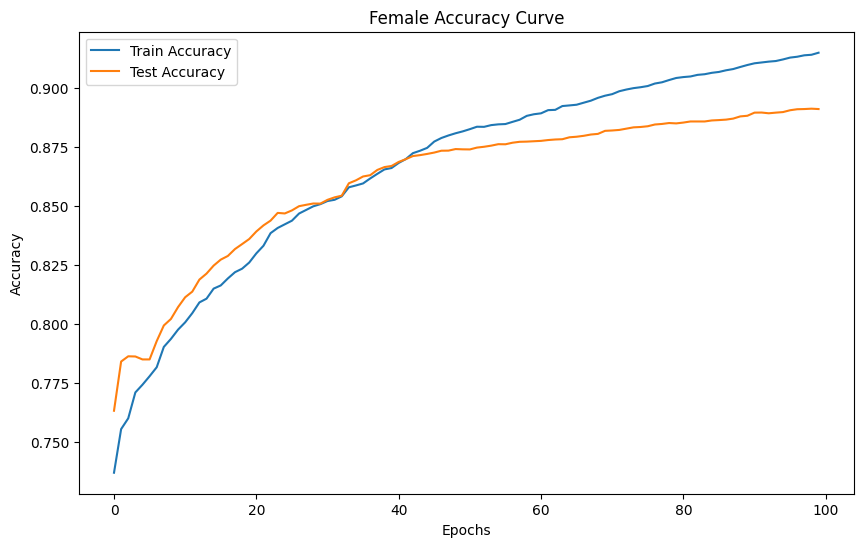

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94     21398
         1.0       0.82      0.07      0.12       607
         2.0       0.65      0.64      0.64      3334
         3.0       1.00      1.00      1.00       306

    accuracy                           0.89     25645
   macro avg       0.85      0.66      0.68     25645
weighted avg       0.89      0.89      0.88     25645



In [2]:
# Split the data
X_train_female, X_val_female, y_train_female, y_val_female = train_test_split(X_female, y_female, test_size=0.2, random_state=42)

# Apply SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_resampled_female, y_train_resampled_female = smote.fit_resample(X_train_female, y_train_female)

# Initialize evaluation sets
eval_set = [(X_train_resampled_female, y_train_resampled_female), (X_val_female, y_val_female)]

female_model = xgb.XGBClassifier(eval_metric='merror', objective='multi:softprob', num_class=4)

female_model.fit(X_train_resampled_female, y_train_resampled_female, eval_set=eval_set, verbose=True)

# Retrieve evaluation results
results = female_model.evals_result()

# Calculate accuracy
train_accuracy = [1 - x for x in results['validation_0']['merror']]
test_accuracy = [1 - x for x in results['validation_1']['merror']]

# Plot accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Female Accuracy Curve')
plt.legend()
plt.savefig('female_accuracy_curve.png')
plt.show()

from sklearn.metrics import classification_report

# Make predictions on the test set
y_prob = female_model.predict_proba(X_val_female)
# Use np.argmax to convert probabilities to class predictions
y_pred = np.argmax(y_prob, axis=1)

# Generate the classification report
report = classification_report(y_val_female, y_pred)
print(report)

In [3]:
male_data = pd.read_csv('/kaggle/input/male-data/male_data.csv')
print(male_data.columns)
male_columns_to_drop = ['Family_Diabetes', 'Smoking', 'Alcohol', 'RegularMedicine', 'Stress', 'Pdiabetes', 'Diabetic', 'Diabetes_Status', 'HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth', 'DiffWalk',
       'Education', 'Income', 'Polyuria', 'Polydipsia', 'weakness', 'Polyphagia', 'Genital thrush', 'Itching', 'Irritability', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'Patient_ID']


X_male = male_data.drop(columns=male_columns_to_drop, axis=1)
y_male = male_data['Diabetes_Status']

print(X_male.columns)

Index(['Age', 'Family_Diabetes', 'HighBP', 'PhysicallyActive', 'BMI',
       'Smoking', 'Alcohol', 'Sleep', 'SoundSleep', 'RegularMedicine',
       'JunkFood', 'Stress', 'BPLevel', 'Pdiabetes', 'UriationFreq',
       'Diabetic', 'Diabetes_Status', 'HighChol', 'CholCheck', 'Stroke',
       'HeartDiseaseorAttack', 'Fruits', 'Veggies', 'AnyHealthcare',
       'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk',
       'Education', 'Income', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'Patient_ID'],
      dtype='object')
Index(['Age', 'HighBP', 'PhysicallyActive', 'BMI', 'Sleep', 'SoundSleep',
       'JunkFood', 'BPLevel', 'UriationFreq', 'Fruits', 'Veggies', 'GenHlth',
       'PhysHlth', 'sudden weight loss', 'visual blurring', 'delayed healing'],
      dtype='object')


[0]	validation_0-merror:0.28621	validation_1-merror:0.23060
[1]	validation_0-merror:0.26578	validation_1-merror:0.22428
[2]	validation_0-merror:0.24851	validation_1-merror:0.20983
[3]	validation_0-merror:0.23421	validation_1-merror:0.20421
[4]	validation_0-merror:0.22330	validation_1-merror:0.19397
[5]	validation_0-merror:0.21697	validation_1-merror:0.18322
[6]	validation_0-merror:0.20882	validation_1-merror:0.17518
[7]	validation_0-merror:0.20313	validation_1-merror:0.16798
[8]	validation_0-merror:0.19389	validation_1-merror:0.15884
[9]	validation_0-merror:0.18833	validation_1-merror:0.15120
[10]	validation_0-merror:0.18442	validation_1-merror:0.14971
[11]	validation_0-merror:0.17995	validation_1-merror:0.14580
[12]	validation_0-merror:0.17643	validation_1-merror:0.14338
[13]	validation_0-merror:0.17507	validation_1-merror:0.14321
[14]	validation_0-merror:0.17123	validation_1-merror:0.13899
[15]	validation_0-merror:0.16791	validation_1-merror:0.13596
[16]	validation_0-merror:0.16423	v

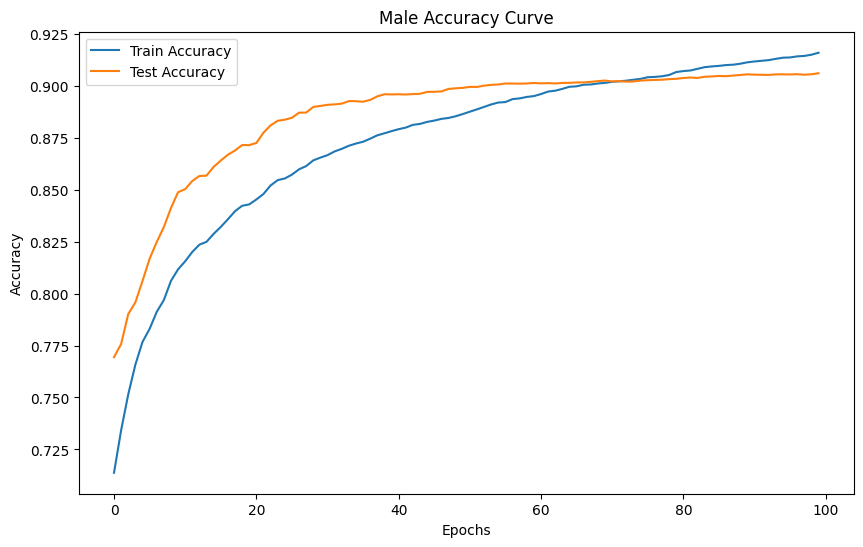

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.95     18703
         1.0       0.83      0.19      0.31       583
         2.0       0.77      0.72      0.74      3485

    accuracy                           0.91     22771
   macro avg       0.84      0.62      0.66     22771
weighted avg       0.90      0.91      0.90     22771



In [4]:
# Split the data
X_train_male, X_val_male, y_train_male, y_val_male = train_test_split(X_male, y_male, test_size=0.2, random_state=42)

# Apply SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_resampled_male, y_train_resampled_male = smote.fit_resample(X_train_male, y_train_male)

# Initialize evaluation sets
eval_set = [(X_train_resampled_male, y_train_resampled_male), (X_val_male, y_val_male)]

male_model = xgb.XGBClassifier(eval_metric='merror', objective='multi:softprob', num_class=3)

male_model.fit(X_train_resampled_male, y_train_resampled_male, eval_set=eval_set, verbose=True)

# Retrieve evaluation results
results = male_model.evals_result()

# Calculate accuracy
train_accuracy = [1 - x for x in results['validation_0']['merror']]
test_accuracy = [1 - x for x in results['validation_1']['merror']]

# Plot accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Male Accuracy Curve')
plt.legend()
plt.savefig('male_accuracy_curve.png')
plt.show()

from sklearn.metrics import classification_report

# Make predictions on the test set
y_prob = male_model.predict_proba(X_val_male)
# Use np.argmax to convert probabilities to class predictions
y_pred = np.argmax(y_prob, axis=1)

# Generate the classification report
report = classification_report(y_val_male, y_pred)
print(report)

In [22]:
# saving male model and female model
male_model.save_model('xgboost_male.json')
female_model.save_model('xgboost_female.json')